In [1]:
# load packages
import sys
import os
import glob
import spikeinterface.extractors as se
import spikeinterface.full as si
from pathlib import Path
from spikeinterface.extractors.neuropixels_utils import get_neuropixels_sample_shifts
import spikeinterface.preprocessing as spre
import numpy as np
import json
import probeinterface as pi
from kilosort import io
from kilosort import run_kilosort

import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
# set params
SAMPLE_RATE = 30000
N_CHANNELS_PROBE = 384
N_CHANNELS_SHANK = 96


In [3]:
# set up fxns
def find_active_channels(probe_dict):
    dev_ind = np.array(probe_dict['probes'][0]["device_channel_indices"])
    return dev_ind != -1

def find_shank_channels(probe_dict, shank_num):
    shank_ind = np.array(probe_dict["shank_ids"]) 
    return shank_ind == str(shank_num)

def load_probe(probe_file, shank_num=None):
    # Load probe configuration file
    with open(probe_file, 'r') as f:
        probe_dict = json.load(f)
    
    active_channels_mask = find_active_channels(probe_dict)
    probe = probe_dict['probes'][0] # get the first probe

    # First filter by active channels
    for key in ['contact_positions', 'contact_plane_axes', 'contact_shapes', 'contact_shape_params', 'device_channel_indices', 'contact_ids', 'shank_ids']:
        probe[key] = np.array(probe[key])[active_channels_mask]

    # Then filter by shank if specified
    if shank_num is not None:
        shank_channels_mask = find_shank_channels(probe, shank_num)
        #shank_channels_mask = shank_channels_mask[active_channels_mask]
        for key in ['contact_positions', 'contact_plane_axes', 'contact_shapes', 'contact_shape_params', 'device_channel_indices', 'contact_ids', 'shank_ids']:
            probe[key] = probe[key][shank_channels_mask]
        try:
            probe['device_channel_indices'] = np.arange(0, 96)
            print(f"set device channel indices to 0-95 for shank {shank_num}")
        except:
            print("could not set device channel indices for 96, trying 192")
            probe['device_channel_indices'] = np.arange(0, 192)
            print(f"set device channel indices to 0-191 for shank {shank_num}")

    probe = pi.Probe.from_dict(probe)
    return probe

def collect_files(data_folder, probe_name):
    '''Collect all files for each probe within data_folder
    Args:
    data_folder (Path): path to the data folder
    probe_name (str): probe name
    output_folder (Path, optional): path to output folder for creating probe directories
    Returns:
    recording_files (dict): dictionary with probe names as keys and list of files as values
    '''

    # Collect all files for probe_x within data_folder
    recording_files = glob.glob(f"{str(data_folder)}/{probe_name}*")

    # Print the number of files found for each probe for user feedback
    print(f'Found {len(recording_files)} files for {probe_name}')

    return recording_files

def get_sample_shifts(n_channels):
    total_channels = 384
    num_channels_per_adc = 16
    num_channels_in_adc = 16 

    sample_shifts = get_neuropixels_sample_shifts(total_channels, num_channels_per_adc, num_channels_in_adc)
    return sample_shifts

def split_recording(recording_files, probe_names, global_probe_data):
    '''Split the recording into shanks
    Args:
    recording_files (dict): dictionary with probe names as keys and list of files as values
    probe_names (list): list of probe names
    global_probe_data (dict): dictionary with global probe data
    Returns:
    shank_dict (dict): dictionary with probe names as keys and shank recordings as values
    '''

    recordings = []
    recording_paths = []
    # Loop through each recording file for probe_x
    for recording_file in recording_files:
        # Load the recording file
        recording = se.read_binary(recording_file, dtype='int16', sampling_frequency=SAMPLE_RATE, num_channels=N_CHANNELS_PROBE)
        # Sanity check for user
        print(recording.get_total_duration())
        # Append the recording to the list and ignore any empty
        if recording.get_num_frames() == 0:
            print(f"Warning: The recording file {recording_file} is empty.")
        else:
            recording.set_probe(global_probe_data)
            sample_shifts = get_sample_shifts(N_CHANNELS_PROBE)
            recording = spre.phase_shift(recording, inter_sample_shift=sample_shifts)
            recordings.append(recording)
            recording_paths.append(recording_file)
    # Concatenate the recordings
    total_recording = si.concatenate_recordings(recordings)
    total_recording.set_probe(global_probe_data)
    total_recording.set_channel_locations(global_probe_data.contact_positions)
    # Set the group property to the shank index
    total_recording = spre.bandpass_filter(total_recording, freq_min=300., freq_max=7500., dtype='int16')
    total_recording = spre.common_reference(total_recording, reference='local', operator='median')
    total_recording.set_property("group", global_probe_data.shank_ids)
    # Split the recording by group
    total_recording = total_recording.split_by("group")
    return total_recording, recording_paths


In [4]:

# optional spikeinterface widgets
try:
    import spikeinterface.widgets as sw
    _has_si_widgets = True
except ImportError:
    _has_si_widgets = False


In [5]:
def plot_shank_preview(recording, fs=None, seconds=2.0, n_channels=16):
    # simple preview of first few channels
    if fs is None:
        fs = float(recording.get_sampling_frequency())
    n_preview = int(seconds * fs)
    n_preview = min(n_preview, recording.get_num_samples())
    n_plot_ch = min(n_channels, recording.get_num_channels())
    traces = recording.get_traces(start_frame=0, end_frame=n_preview)[:, :n_plot_ch]
    t = np.arange(traces.shape[0]) / fs

    offset = np.nanstd(traces) * 3 if np.nanstd(traces) > 0 else 100
    plt.figure(figsize=(10, 6))
    for ch in range(n_plot_ch):
        plt.plot(t, traces[:, ch] + ch * offset)
    plt.xlabel("time (s)")
    plt.ylabel("channel (offset)")
    plt.title("shank preview")
    plt.tight_layout()
    plt.show()


def plot_probe_layout_si(recording):
    # spikeinterface probe widget
    if not _has_si_widgets:
        print("spikeinterface.widgets not available")
        return
    sw.ProbeWidget(recording).show()


def plot_traces_widget_si(recording, time_start=0.0, time_end=None):
    # spikeinterface traces widget
    if not _has_si_widgets:
        print("spikeinterface.widgets not available")
        return
    if time_end is None:
        time_end = min(2.0, recording.get_total_duration())
    sw.TracesWidget(recording, time_range=(time_start, time_end)).show()


def plot_spike_counts_per_cluster(clu):
    # simple spike count bar plot per cluster
    if clu is None or not hasattr(clu, "shape"):
        print("no cluster array available")
        return
    unique_clu, counts = np.unique(clu, return_counts=True)
    plt.figure(figsize=(10, 4))
    plt.bar(unique_clu, counts)
    plt.xlabel("cluster id")
    plt.ylabel("spike count")
    plt.title("spike counts per cluster")
    plt.tight_layout()
    plt.show()

In [6]:
import time


def run_kilosort_notebook(
    folder,
    probe,
    shank_num,
    probe_amp_suffix=False,
    verbose=True,
):
    """
    notebook-friendly wrapper around existing pipeline
    no plotting inside; use helper functions below for diagnostics
    """

    # normalize inputs
    folder = Path(folder)
    shank_num = str(shank_num)

    # basic path setup
    data_folder = folder / "data"
    output_folder = folder / "output"
    suffix = "amp" if probe_amp_suffix else "ephys"
    probe_name = f"np2-{probe}-{suffix}"
    probe_file = folder / f"{probe}_probe_conf.json"

    # basic existence checks
    if verbose:
        print(f"base folder:   {folder}")
        print(f"data folder:   {data_folder}")
        print(f"output folder: {output_folder}")
        print(f"probe name:    {probe_name}")
        print(f"probe file:    {probe_file}")
        print(f"shank:         {shank_num}")

    if not folder.exists():
        raise FileNotFoundError(f"folder does not exist: {folder}")
    if not data_folder.exists():
        raise FileNotFoundError(f"data folder does not exist: {data_folder}")
    if not probe_file.exists():
        raise FileNotFoundError(f"probe configuration file not found: {probe_file}")

    # load probe config (global, all shanks)
    if verbose:
        print("\nloading global probe description...")
    probe_data = load_probe(probe_file)

    # collect binary files
    if verbose:
        print("\ncollecting recording files...")
    recording_files = collect_files(data_folder, probe_name)
    if len(recording_files) == 0:
        raise RuntimeError(f"no recording files found for {probe_name} in {data_folder}")

    # run your existing split_recording pipeline
    if verbose:
        print("\nloading and preprocessing recordings (bandpass + local ref)...")
    total_recording, recording_paths = split_recording(recording_files, probe_name, probe_data)

    # show per-file durations as quick sanity check
    if verbose:
        print("\nper-file durations (s):")
    file_durations = {}
    for fp in recording_paths:
        rec_tmp = se.read_binary(fp, dtype="int16", sampling_frequency=SAMPLE_RATE, num_channels=N_CHANNELS_PROBE)
        dur = rec_tmp.get_total_duration()
        file_durations[fp] = dur
        print(f"  {os.path.basename(fp)} : {dur:.1f} s")

    # check that desired shank exists
    if shank_num not in total_recording:
        raise KeyError(f"shank {shank_num} not found; available groups: {list(total_recording.keys())}")

    # create output dirs
    output_folder.mkdir(parents=True, exist_ok=True)
    probe_folder = output_folder / probe
    probe_folder.mkdir(parents=True, exist_ok=True)
    shank_folder = probe_folder / f"shank_{shank_num}"
    shank_folder.mkdir(parents=True, exist_ok=True)
    if verbose:
        print(f"\nshank output folder: {shank_folder}")

    # restrict to this shank and set shank-specific probe geometry
    if verbose:
        print("\nconfiguring shank-specific probe...")
    shank_probe = load_probe(probe_file, shank_num)
    total_recording[shank_num] = total_recording[shank_num].set_probe(shank_probe)
    rec = total_recording[shank_num]

    # basic recording summary
    try:
        fs = float(rec.get_sampling_frequency())
        n_ch = int(rec.get_num_channels())
        n_samp = int(rec.get_num_samples())
        dur_min = n_samp / fs / 60.0
        if verbose:
            print("\nshank recording summary:")
            print(f"  fs (Hz):          {fs:.2f}")
            print(f"  n channels:       {n_ch}")
            print(f"  n samples:        {n_samp}")
            print(f"  duration (min):   {dur_min:.1f}")
    except Exception as e:
        if verbose:
            print(f"could not summarize recording: {e}")
        fs = SAMPLE_RATE  # fallback

    # export to binary for kilosort
    if verbose:
        print("\nsaving shank recording to binary for kilosort...")
        start_time = time.time()
        print(f"initial time is {start_time}") # in seconds
    filename, N, c, s, fs_export, probe_path = io.spikeinterface_to_binary(
        rec,
        shank_folder,
        data_name="shank_recording.bin",
        dtype=np.int16,
        chunksize=30000 * 8,
        export_probe=True,
        probe_name="probe.prb",
        max_workers=8,
    )
    if verbose:
        print(f"finished saving binary at {time.time()}, elapsed time {time.time() - start_time:.2f} seconds") # in seconds

    if verbose:
        print(f"  binary file:    {filename}")
        print(f"  N samples:      {N}")
        print(f"  n channels:     {c}")
        print(f"  bytes/sample:   {s}")
        print(f"  fs export (Hz): {fs_export}")

    # load kilosort probe
    assert probe_path is not None, "no probe information exported by spikeinterface"
    if verbose:
        print("\nloading kilosort probe description...")
    kilosort_probe = io.load_probe(probe_path)

    # run kilosort
    if verbose:
        print("\nrunning kilosort...")
    settings = {
        "fs": fs_export,
        "n_chan_bin": c,
        "batch_size": 30000 * 8,
        "Th": [10, 6],
    }

    ops, st, clu, tF, Wall, similar_templates, is_ref, est_contam_rate, kept_spikes = run_kilosort(
        settings=settings,
        probe=kilosort_probe,
        filename=filename,
    )

    # basic summary of ks output
    if verbose:
        n_spikes = st.shape[0] if hasattr(st, "shape") else None
        n_units = len(np.unique(clu)) if clu is not None else None
        print("\nkilosort output summary:")
        print(f"  n spikes:   {n_spikes}")
        print(f"  n clusters: {n_units}")
        if est_contam_rate is not None:
            try:
                print(f"  mean est contam: {np.mean(est_contam_rate):.3f}")
            except Exception:
                pass

    # return everything for later analysis and plotting
    return dict(
        ops=ops,
        st=st,
        clu=clu,
        tF=tF,
        Wall=Wall,
        similar_templates=similar_templates,
        is_ref=is_ref,
        est_contam_rate=est_contam_rate,
        kept_spikes=kept_spikes,
        shank_folder=shank_folder,
        binary_filename=filename,
        settings=settings,
        recording=rec,
        sampling_frequency=fs_export,
        file_durations=file_durations,
    )

In [7]:
# run pipeline

folder = Path(r"V:\neuropixels_2025\npx08\2025_12_02_square_arena_02")
probe = "b"
shank_num = 1


results = run_kilosort_notebook(
    folder=folder,
    probe=probe,
    shank_num=shank_num,
    verbose=True,
)

base folder:   V:\neuropixels_2025\npx08\2025_12_02_square_arena_02
data folder:   V:\neuropixels_2025\npx08\2025_12_02_square_arena_02\data
output folder: V:\neuropixels_2025\npx08\2025_12_02_square_arena_02\output
probe name:    np2-b-ephys
probe file:    V:\neuropixels_2025\npx08\2025_12_02_square_arena_02\b_probe_conf.json
shank:         1

loading global probe description...

collecting recording files...
Found 1 files for np2-b-ephys

loading and preprocessing recordings (bandpass + local ref)...
2424.983

per-file durations (s):
  np2-b-ephys_2025-12-02T15_56_10.raw : 2425.0 s

shank output folder: V:\neuropixels_2025\npx08\2025_12_02_square_arena_02\output\b\shank_1

configuring shank-specific probe...
set device channel indices to 0-95 for shank 1

shank recording summary:
  fs (Hz):          30000.00
  n channels:       96
  n samples:        72749490
  duration (min):   40.4

saving shank recording to binary for kilosort...
initial time is 1764778559.1735744


kilosort.run_kilosort: Kilosort version 4.0.18
kilosort.run_kilosort: Sorting V:\neuropixels_2025\npx08\2025_12_02_square_arena_02\output\b\shank_1\shank_recording.bin
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: Interpreting binary file as default dtype='int16'. If data was saved in a different format, specify `data_dtype`.
kilosort.run_kilosort: Using GPU for PyTorch computations. Specify `device` to change this.
kilosort.run_kilosort:  
kilosort.run_kilosort: Computing preprocessing variables.
kilosort.run_kilosort: ----------------------------------------


finished saving binary at 1764781199.3858898, elapsed time 2640.21 seconds
  binary file:    V:\neuropixels_2025\npx08\2025_12_02_square_arena_02\output\b\shank_1\shank_recording.bin
  N samples:      72749490
  n channels:     96
  bytes/sample:   1
  fs export (Hz): 30000.0

loading kilosort probe description...

running kilosort...


kilosort.run_kilosort: N samples: 72749490
kilosort.run_kilosort: N seconds: 2424.983
kilosort.run_kilosort: N batches: 304
kilosort.run_kilosort: Preprocessing filters computed in  2.53s; total  2.53s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after preprocessing
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    24.00 %
kilosort.run_kilosort: Memory:       26.88 %     |    137.56   /   511.85 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   14.93 %     |      2.39   /    15.99 GB
kilosort.run_kilosort: Allocated:     0.05 %     |      0.01   /    15.99 GB
kilosort.run_kilosort: Max alloc:     4.90 %     |      0.78   /    15.99 GB
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort:  
kilosort.run_kilosort: Co


kilosort output summary:
  n spikes:   4365609
  n clusters: 156
  mean est contam: 0.353


In [8]:
# plot
rec = results["recording"]
fs = results["sampling_frequency"]
clu = results["clu"]


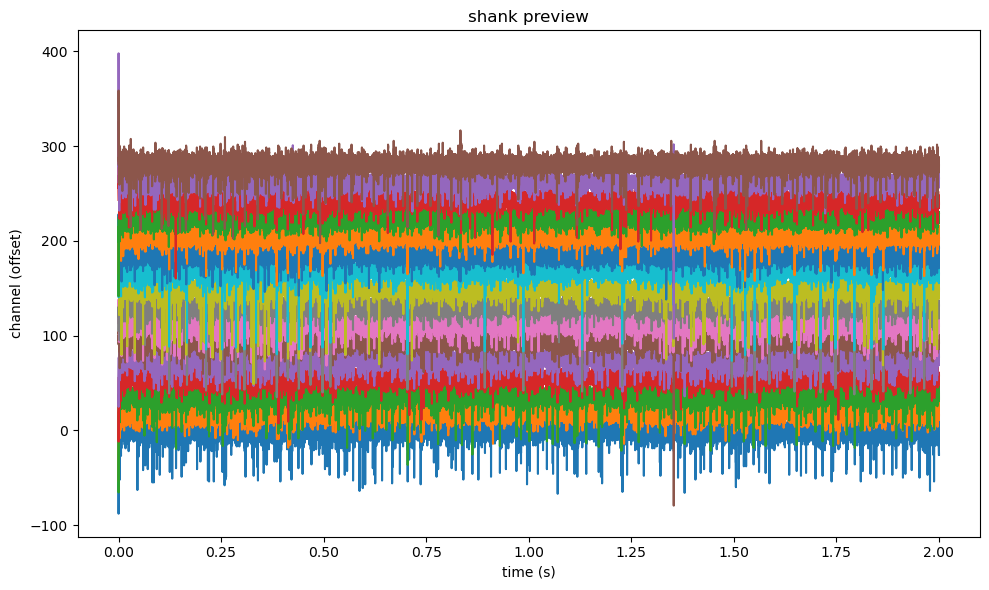

In [9]:

# in a later cell: basic preview of traces
plot_shank_preview(rec, fs=fs, seconds=2.0, n_channels=16)


In [11]:

# in another cell: optional si widgets
plot_probe_layout_si(rec)
plot_traces_widget_si(rec, time_start=0.0, time_end=2.0)


AttributeError: module 'spikeinterface.widgets' has no attribute 'ProbeWidget'